In [1]:
%config InlineBackend.figure_format = 'retina'

In [2]:
import matplotlib as mpl
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl
import seaborn as sns
from scipy import stats

from dv_score import io, util

from dv_score.viz import moe_style_context, viz
import dv_score.retinoic as ra

In [3]:
sns.set_theme(font_scale=1, style="ticks", palette="tab10", context="talk")

# RA manipulations
* Aldh1a2 inhibitor Win 18,446 (**RA Inh.**) and all-trans RA (**atRA**)
* scRNA-seq post-regeneration and drug treatment (to look at effects on OSN frequency)

In [4]:
WT = "dmso"
KO = "inh"
OE = "OE"
GENOS = (WT, KO)
ALL_GENOS = (WT, KO, OE)
D_OE = (WT, OE)
KO_OE = (KO, OE)

new_cols = ["RA Inh.", "atRA"]
name_map = dict(zip(KO_OE, new_cols))
ra_pal = [plt.cm.Set1(1), plt.cm.Set1(0)]
ra_cmap = dict(zip(KO_OE, ra_pal))

# respective DMSO control for each drug
control_map = {OE: "OE_dmso", KO: WT}

In [5]:
df_wt_dv = io.load_ra()
df_wt_oe = df_wt_dv[df_wt_dv["is_OE_batch"]]
df_wt_inh = df_wt_dv[~df_wt_dv["is_OE_batch"]]
df_map = {KO: df_wt_inh, OE: df_wt_oe}


In [6]:
starts = np.arange(-400, 251, step=10)
df_norm_plot, df_mouse_sum = ra.delta_or(
    df_wt_dv, starts=starts, bin_width=100, only_c2=True
)

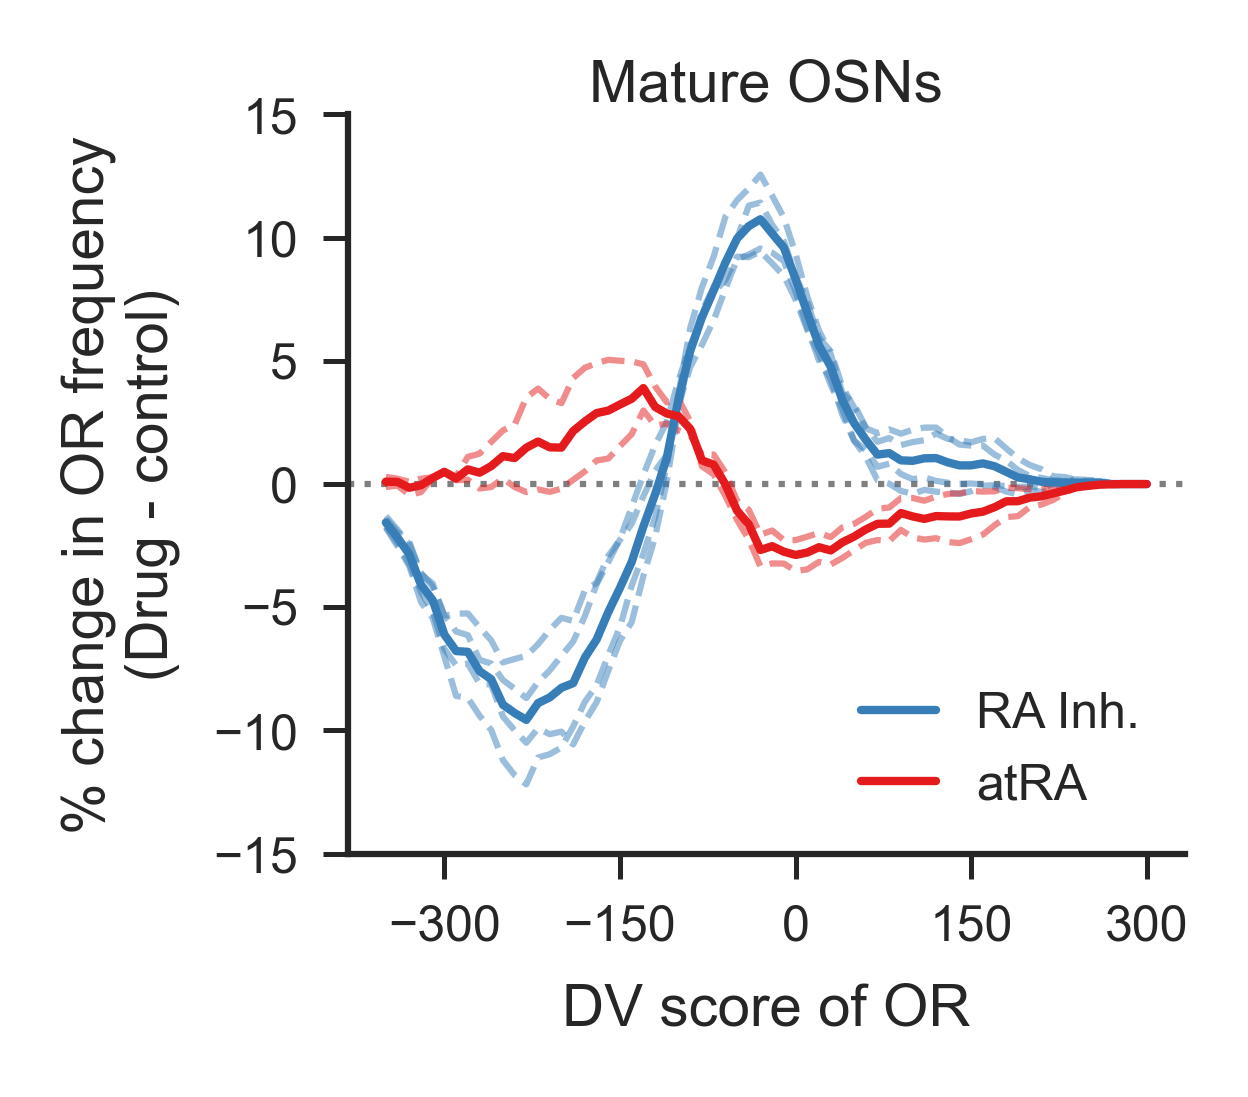

In [7]:
with moe_style_context():
    fig, ax = plt.subplots(figsize=(1.8, 1.6))
    new_starts = starts + 50
    for k, df in df_map.items():
        mouse_map = df.groupby("geno").orig_ident.unique()
        y = df_mouse_sum.loc[mouse_map.loc[k]] - df_mouse_sum.loc[mouse_map.loc[WT]].mean(0)
        to_plot = (df_norm_plot.loc[k] - df_norm_plot.loc[control_map[k]])
        ax.plot(
            new_starts,
            y.T,
            color=ra_cmap[k],
            lw=0.75,
            alpha=0.5,
            ls="--",
        )
        ax.plot(new_starts, to_plot, lw=1, color=ra_cmap[k], label=name_map[k], zorder=5)

    ax.set_ylabel("% change in OR frequency\n(Drug - control)")
    ax.axhline(0, ls=":", color="k", alpha=0.5, zorder=-5, lw=0.75)
    sns.despine()
    ax.set_xlabel("DV score of OR")
    ax.xaxis.set_major_locator(mpl.ticker.MultipleLocator(150))
    ax.yaxis.set_major_locator(mpl.ticker.MultipleLocator(5))
    ax.legend(handlelength=1.5, loc="lower right", bbox_to_anchor=(1, 0))
    ax.set_ylim(-15, 15)
    ax.set_title("Mature OSNs", y=0.95)

## log fold-change

In [8]:
edges = np.arange(101, step=10)
bin_ct_norm, ci_dict = ra.log_fc(df_wt_dv, control_map, edges)

100%|█████████████████████████████████████████| 100/100 [00:07<00:00, 13.58it/s]


(-1.2, 0.987752673523419)

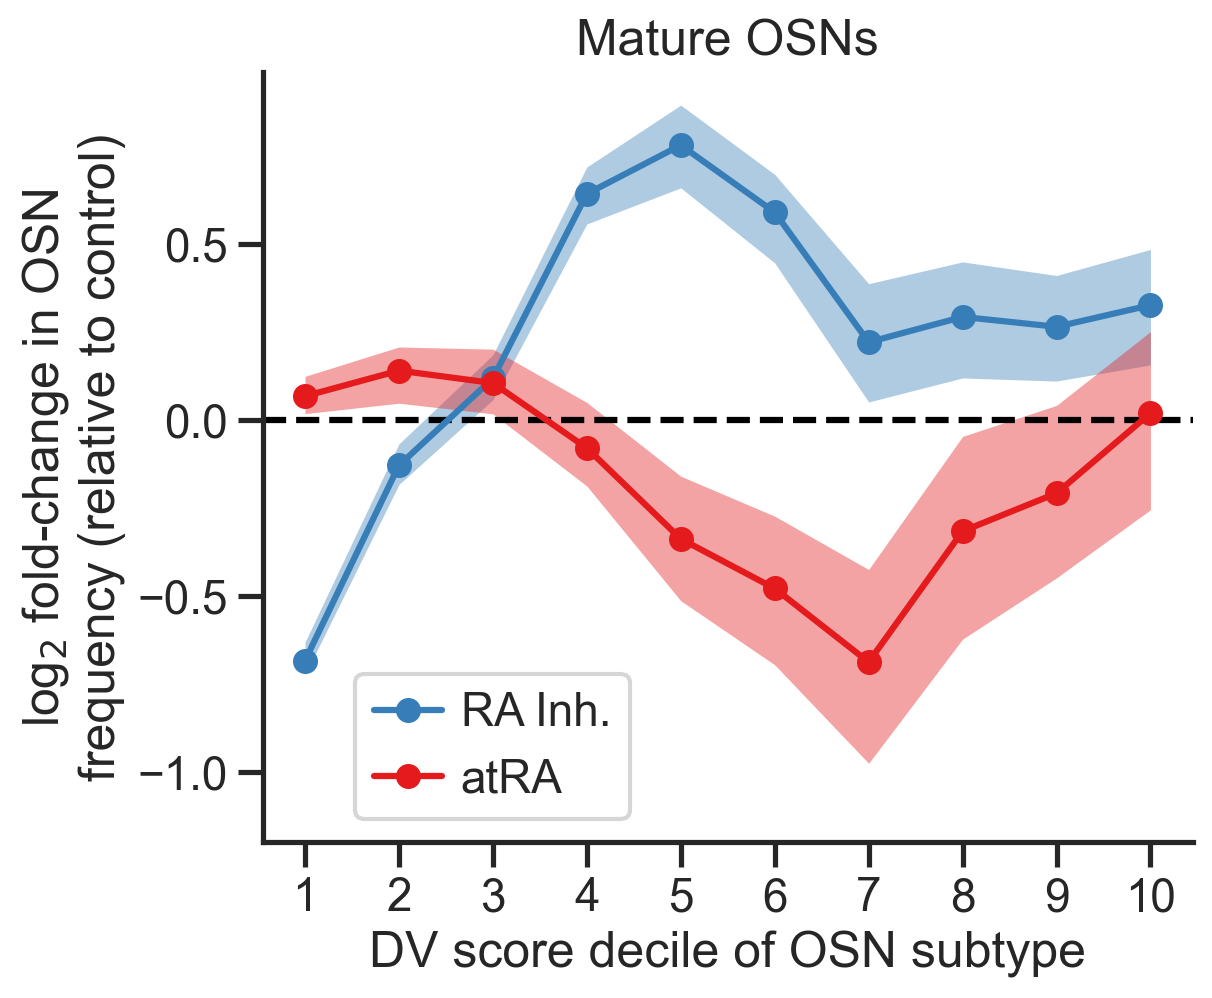

In [9]:
xn = np.arange(10) + 1

fig, ax = plt.subplots(figsize=(6,5))
ax.axhline(0, ls="--", color="k")
for g in KO_OE:
    ratio = np.log2(bin_ct_norm[g] / bin_ct_norm[control_map[g]])
    ax.plot(xn, ratio, ".-", color=ra_cmap[g], ms=16, label=name_map[g])
    ax.fill_between(xn, *ci_dict[g], color=ra_cmap[g], alpha=0.4, lw=0)
    
sns.despine()
ax.legend(handletextpad=0.4, loc="lower left", handlelength=1.5, bbox_to_anchor=(0.075, 0))
ax.set_ylabel("log$_2$ fold-change in OSN\nfrequency (relative to control)")
ax.set_xticks(xn)
ax.set_xlabel("DV score decile of OSN subtype")
ax.set_title("Mature OSNs")
ax.set_ylim(-1.2, None)

In [10]:
outs = {}
for k, df in df_wt_dv.groupby("is_OE_batch"):
    wt_med = df[df.geno == WT].DV_score.median()
    df["delta_DV"] = df.DV_score - wt_med
    outs[k] = df.groupby(["geno", "geno2", "orig_ident"]).delta_DV.median()
df_med_delta =pd.concat(outs).reset_index()
df_med_plot = df_med_delta[df_med_delta.geno != WT]

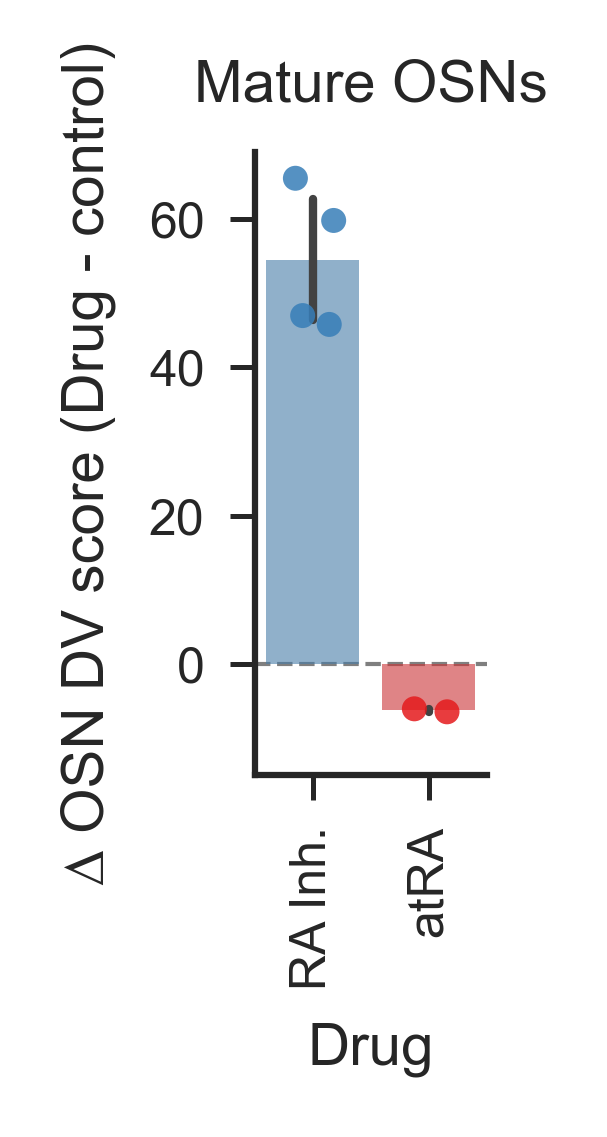

In [11]:
with moe_style_context():
    fig, ax = plt.subplots(figsize=(0.5, 1.35))
    np.random.seed(74)
    sns.stripplot(
        data=df_med_plot,
        x="geno",
        y="delta_DV",
        order=KO_OE,
        hue_order=KO_OE,
        hue="geno",
        palette=ra_pal,
        s=3,
        jitter=0.25,
        alpha=0.85,
    )
    sns.barplot(
        data=df_med_plot,
        x="geno",
        y="delta_DV",
        order=KO_OE,
        hue_order=KO_OE,
        hue="geno",
        palette=ra_pal,
        err_kws={"linewidth": 1},
        lw=0,
        alpha=0.6,
    )
    sns.despine()
    ax.set_xticks([0, 1])
    ax.set_xticklabels(new_cols, rotation=90)
    ax.set_xlabel("Drug")
    ax.set_ylim(-15, None)
    ax.axhline(0, ls="--", alpha=0.5, zorder=-10, lw=0.5, color="k")
    ax.set_title("Mature OSNs")
    ax.set_ylabel("∆ OSN DV score (Drug - control)")
    ax.yaxis.set_major_locator(mpl.ticker.MultipleLocator(20))

## DV score of cell vs OR

In [12]:
cuts = np.arange(-400, 301, 50)
cut_half = (cuts[:-1] + cuts[1:]) // 2
df_wt_dv["dv_bin"] = pd.cut(df_wt_dv["DV_score"].clip(-400, 300), cuts, include_lowest=True)
df_wt_dv["dv_bin_code"] = df_wt_dv.dv_bin.cat.codes

df_qt_mean = (
    io.load_df_dv(add_qt=True)
    .group_by("top_Olfr")
    .agg(pl.col("DV_qt").mean())
    .to_pandas()
)
df_res = df_wt_dv.merge(df_qt_mean, on="top_Olfr", how="left")
df_res_mean = df_res.groupby(["dv_bin_code", "geno"]).DV_qt.mean().unstack()
cis = df_res.groupby(["geno", "dv_bin_code"]).DV_qt.apply(
    util.get_ci_vect_vectorized
)

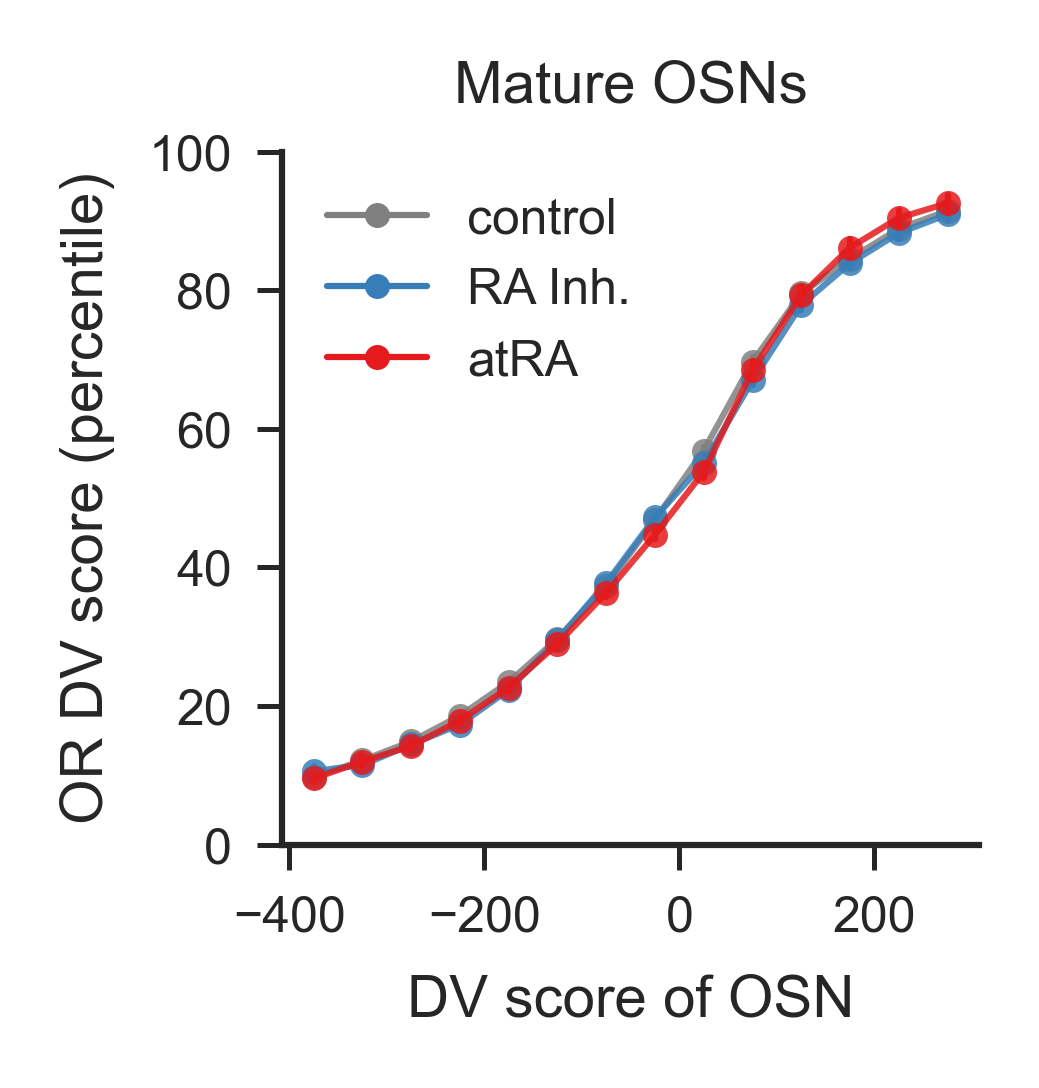

In [13]:
with moe_style_context():
    fig, ax = plt.subplots(figsize=(1.5, 1.5))
    all_pal = ["0.5"] + ra_pal
    names = ["control"] + new_cols
    for i, c in enumerate(ALL_GENOS):
        ax.plot(
            cut_half,
            df_res_mean[c],
            ".-",
            ms=6,
            label=names[i],
            color=all_pal[i],
            lw=0.75,
            alpha=0.85,
        )
        ax.plot([cut_half, cut_half], np.stack(cis.loc[c]).T, color=all_pal[i], lw=0.75)
    ax.set_ylim(0, 100)
    ax.yaxis.set_major_locator(mpl.ticker.MultipleLocator(20))
    ax.xaxis.set_major_locator(mpl.ticker.MultipleLocator(200))
    sns.despine()
    ax.set_xlabel("DV score of OSN")
    ax.set_ylabel("OR DV score (percentile)")
    ax.set_title("Mature OSNs")
    leg = ax.legend()
    for lh in leg.legend_handles:
        lh.set_alpha(1)

## RAR inhibitor

In [14]:
RAR = "RAR"
DMSO = "DMSO"
rar_name = "RAR Inh."
rar_color = plt.cm.tab20b(0)
shuff_color = "0.6"
new_cmap = dict({DMSO: shuff_color, RAR: rar_color})
new_labels = dict({DMSO: "control", RAR: rar_name})
control_map_rar = {RAR: DMSO}

In [15]:
df_wt_dv_rar = io.load_ra(rar=True)

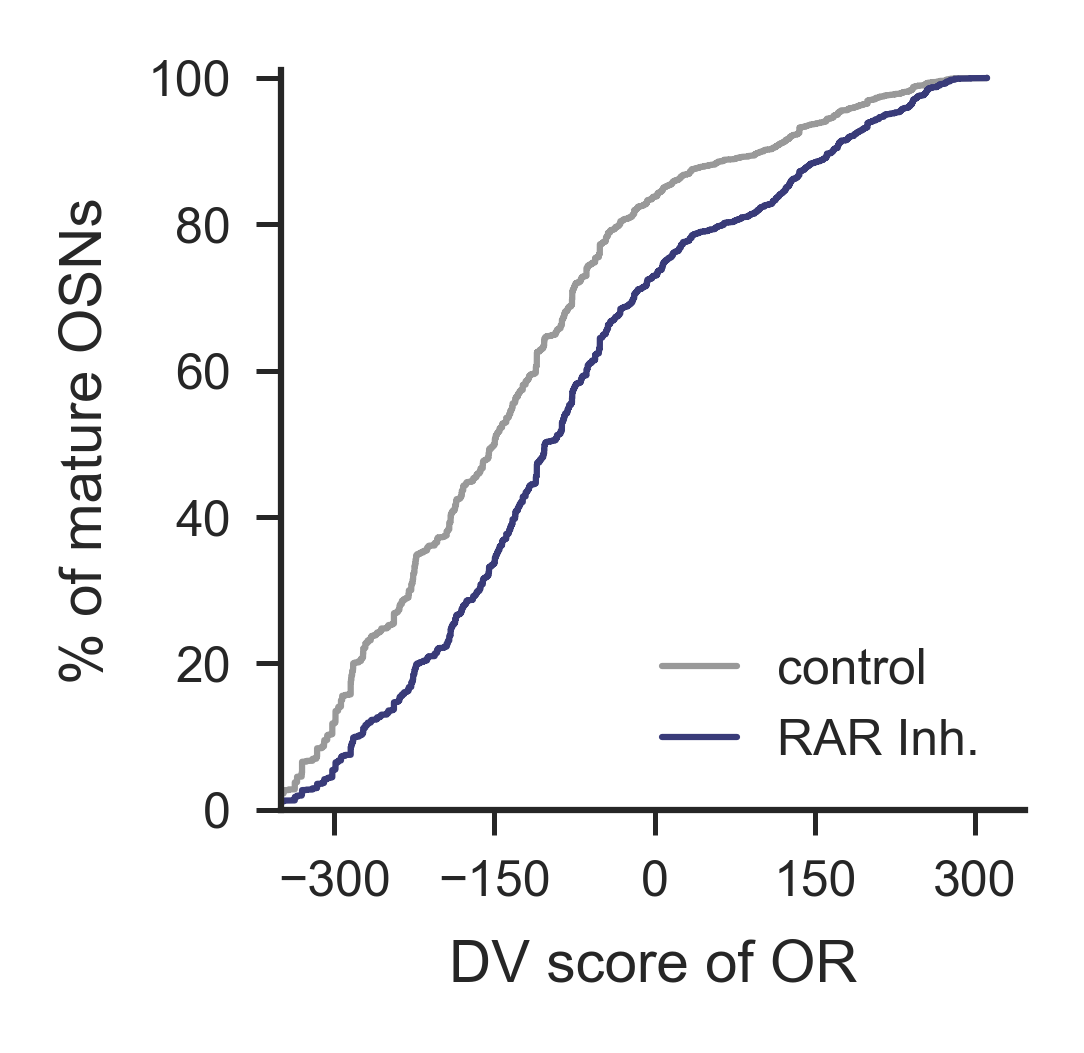

In [16]:
with moe_style_context():
    fig, ax = plt.subplots(figsize=(1.6, 1.6))
    for k, _df in df_wt_dv_rar.groupby("cond"):
        _x, _y = viz.get_step(_df.DV)
        ax.plot(_x, _y * 100, lw=0.75, color=new_cmap[k], label=new_labels[k])
    ax.set_xlabel("DV score of OR")
    ax.set_ylabel("% of mature OSNs")
    sns.despine()
    ax.set_ylim(0, 101)
    ax.set_xlim(-350, None)
    ax.xaxis.set_major_locator(mpl.ticker.MultipleLocator(150))
    ax.yaxis.set_major_locator(mpl.ticker.MultipleLocator(20))
    ax.legend(handlelength=1.5)

In [17]:
edges = np.arange(101, step=10)
bin_ct_norm, ci_dict = ra.log_fc(df_wt_dv_rar, control_map_rar, edges, cond_col="cond")

100%|█████████████████████████████████████████| 100/100 [00:04<00:00, 21.76it/s]


Text(0.5, 1, 'RAR inhibitor (BMS493) vs. control')

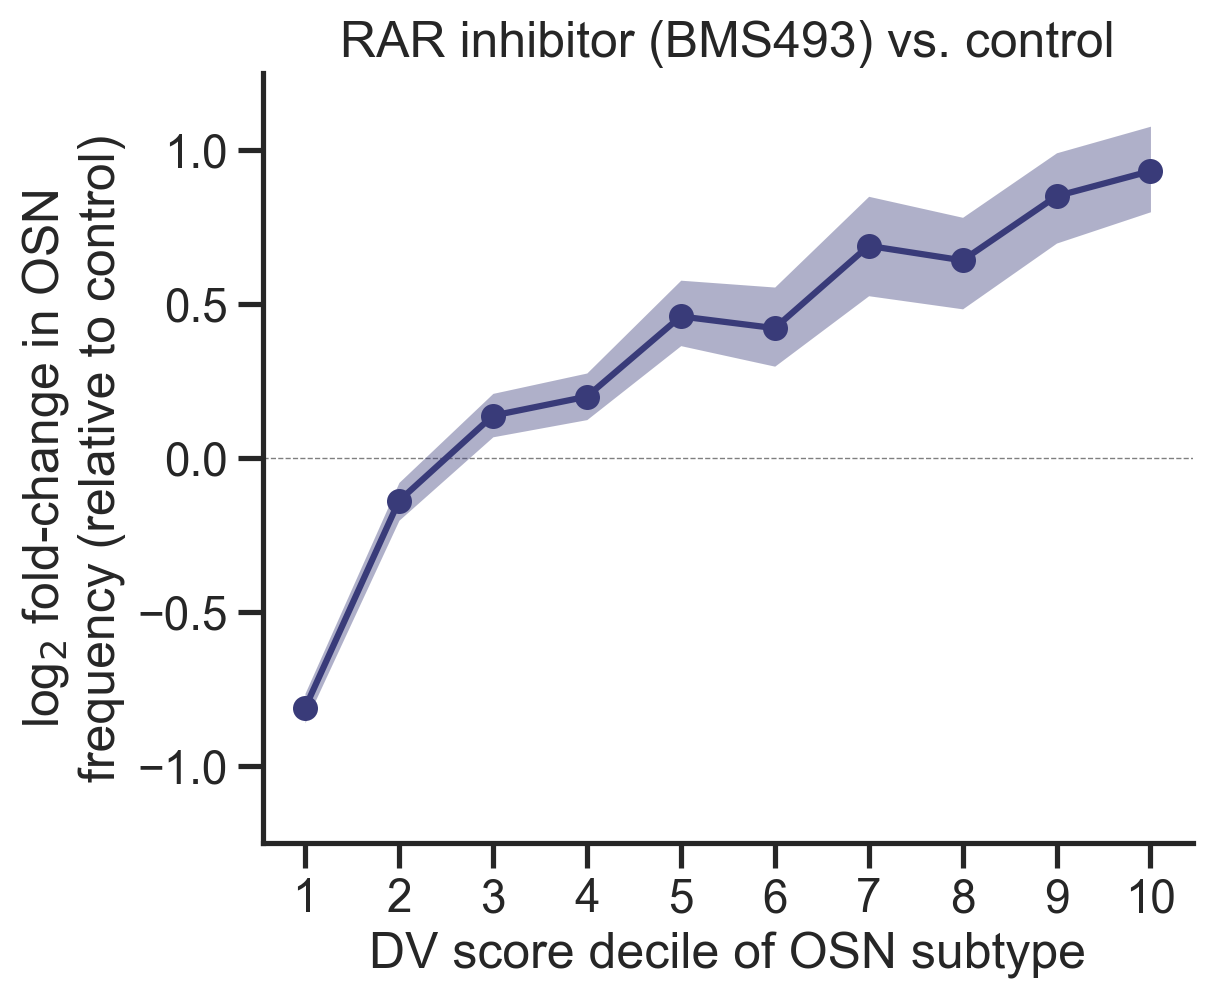

In [18]:
fig, ax = plt.subplots(figsize=(6,5))
ax.axhline(0, ls="--", color="k", lw=0.5, alpha=0.5, zorder=-10)
for g in (RAR,):
    ratio = np.log2(bin_ct_norm[g] / bin_ct_norm[control_map_rar[g]])
    ax.plot(xn, ratio, ".-", color=new_cmap[g], ms=16, label=new_labels[g])
    ax.fill_between(xn, *ci_dict[g], color=new_cmap[g], alpha=0.4, lw=0)
sns.despine()
ax.set_ylabel("log$_2$ fold-change in OSN\nfrequency (relative to control)")
ax.set_xticks(xn)
ax.set_xlabel("DV score decile of OSN subtype")
ax.set_ylim(-1.25, 1.25)
ax.set_title("RAR inhibitor (BMS493) vs. control", y=1)

In [19]:
olfr_mix = [
    "Olfr17",
    "Olfr76",
    "Olfr393",
    "Olfr713",
    "Olfr873",
    "Olfr1302",
    "Olfr1341",
    "Olfr1370",
    "Olfr1490",
]

count_pal = [shuff_color, rar_color]
count_names = ["control", rar_name]

df_wt_dv_rar["is_olfr_mix"] = df_wt_dv_rar["top_Olfr"].isin(olfr_mix)
df_mix_pct = df_wt_dv_rar.groupby(["cond", "orig_ident"], as_index=False).is_olfr_mix.mean()
df_mix_pct["per_mill"] = df_mix_pct["is_olfr_mix"] * 1e3

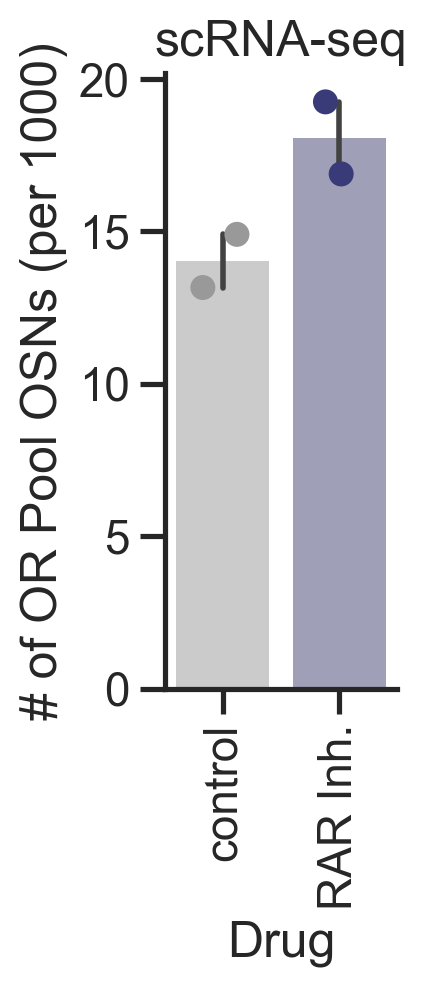

In [20]:
np.random.seed(12)
fig, ax = plt.subplots(figsize=(1.5, 4))
sns.stripplot(
    data=df_mix_pct,
    x="cond",
    y="per_mill",
    hue="cond",
    size=9,
    palette=count_pal,
    jitter=0.25
)
sns.barplot(
    data=df_mix_pct,
    x="cond",
    y="per_mill",
    hue="cond",
    lw=0,
    err_kws={"lw": 2},
    alpha=0.5,
    palette=count_pal,
)
sns.despine()
ax.set_xlabel("Drug")
ax.set_xticks([0, 1])
ax.set_xticklabels(count_names, rotation=90)
ax.set_ylabel(f"# of OR Pool OSNs (per 1000)")
ax.set_title("scRNA-seq")
sns.despine()